# Multiclass Iris Classification with One-Hot Labels

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import OneHotEncoder

## Dataset

In [2]:
path = "iris.csv"
dataset = pd.read_csv(path)

print(dataset.columns.values)

['Id' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm'
 'Species']


In [3]:
# Load the alternate Iris file and assign column names

path = "irisNoNames.csv"

dataset = pd.read_csv(path)

columnNames = ['Id', 'SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm','Species']
dataset.columns = columnNames

print(dataset.columns.values)
dataset

['Id' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm'
 'Species']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,2,4.9,3.0,1.4,0.2,Iris-setosa
1,3,4.7,3.2,1.3,0.2,Iris-setosa
2,4,4.6,3.1,1.5,0.2,Iris-setosa
3,5,5.0,3.6,1.4,0.2,Iris-setosa
4,6,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...,...
144,146,6.7,3.0,5.2,2.3,Iris-virginica
145,147,6.3,2.5,5.0,1.9,Iris-virginica
146,148,6.5,3.0,5.2,2.0,Iris-virginica
147,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
X = dataset[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
target = dataset['Species']
print(target)
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(np.array(target).reshape(-1, 1))
print(y)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
144    Iris-virginica
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
Name: Species, Length: 149, dtype: object
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 

## Train-test split

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.3,
    random_state=10
)
print(len(dataset))
print(len(x_train))
print(len(x_test))


149
104
45


In [8]:
print(x_train.shape)
print(y_train.shape)
print(y_train[:10])

(104, 4)
(104, 3)
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


## TensorFlow model

### Architecture

In [9]:
model = Sequential(
    [ 
        Dense(16, activation = 'relu'),
        Dense(32, activation = 'relu'),
        Dense(3, activation = 'softmax') 
    ]
)

In [10]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(), 
    optimizer=tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

model.fit(
    x_train,y_train,
    epochs=200,
    validation_split=0.1
)

Epoch 1/200


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.3175 - loss: 3.0556 - val_accuracy: 0.4545 - val_loss: 2.0975
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3410 - loss: 2.7603 - val_accuracy: 0.4545 - val_loss: 1.8962
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3136 - loss: 2.5312 - val_accuracy: 0.4545 - val_loss: 1.7128
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3214 - loss: 2.2518 - val_accuracy: 0.4545 - val_loss: 1.5634
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2980 - loss: 2.2126 - val_accuracy: 0.4545 - val_loss: 1.4356
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2941 - loss: 1.9525 - val_accuracy: 0.4545 - val_loss: 1.3214
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3371 - loss: 1.6880 - val_accuracy: 0.4545 - val_loss: 1.2185
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3254 - loss: 1.6652 - val_accuracy: 0.4545 - val_loss: 1.1277
Epo

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171 (8.48 KB)

 Trainable params: 723 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,448 (5.66 KB)

### Predictions

In [12]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy * 100:.2f}%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9495 - loss: 0.1291
Test loss: 0.1156
Test accuracy: 95.56%


In [13]:
# Generate predictions with model.predict()
print("prediction:")
print(x_test[0:3])
print(y_test[0:3])
prediction = model.predict(x_test[:3])
print(prediction)

prediction:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
81             5.8           2.7            3.9           1.2
132            6.3           2.8            5.1           1.5
10             4.8           3.4            1.6           0.2
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[6.7042615e-03 9.8728520e-01 6.0104746e-03]
 [5.5752503e-04 3.2426623e-01 6.7517626e-01]
 [9.9484032e-01 5.1596914e-03 8.1327451e-09]]


In [14]:
predictions = model.predict(x_test)
print("predictions = \n", predictions[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
predictions = 
 [[6.7042587e-03 9.8728526e-01 6.0104751e-03]
 [5.5752485e-04 3.2426620e-01 6.7517638e-01]
 [9.9484032e-01 5.1596942e-03 8.1327602e-09]
 [5.6840940e-03 9.8543531e-01 8.8805798e-03]
 [3.0932990e-03 8.7268442e-01 1.2422225e-01]]


In [15]:
y_pred = []

for i in range(len(predictions)):
    y_pred.append(np.argmax(predictions[i]))
    print( f"{predictions[i]}, category: {np.argmax(predictions[i])}")


[0.00670426 0.98728526 0.00601048], category: 1
[5.5752485e-04 3.2426620e-01 6.7517638e-01], category: 2
[9.9484032e-01 5.1596942e-03 8.1327602e-09], category: 0
[0.00568409 0.9854353  0.00888058], category: 1
[0.0030933  0.8726844  0.12422225], category: 1
[0.02200598 0.97186154 0.00613244], category: 1
[0.00508896 0.94896555 0.04594545], category: 1
[0.0032819  0.738428   0.25829014], category: 1
[9.9748611e-01 2.5139113e-03 1.3799353e-09], category: 0
[2.5119731e-05 2.2309598e-02 9.7766536e-01], category: 2
[2.9628718e-05 3.1318445e-02 9.6865189e-01], category: 2
[1.6448201e-05 1.0642119e-02 9.8934138e-01], category: 2
[0.00672304 0.9866455  0.00663146], category: 1
[9.9585307e-01 4.1470081e-03 5.9178147e-09], category: 0
[9.9478066e-01 5.2194083e-03 3.9285144e-09], category: 0
[2.9262496e-06 6.9774399e-03 9.9301958e-01], category: 2
[1.3359544e-04 7.3511772e-02 9.2635465e-01], category: 2
[9.9629027e-01 3.7097228e-03 2.8717844e-09], category: 0
[9.9883622e-01 1.1638070e-03 4.343808

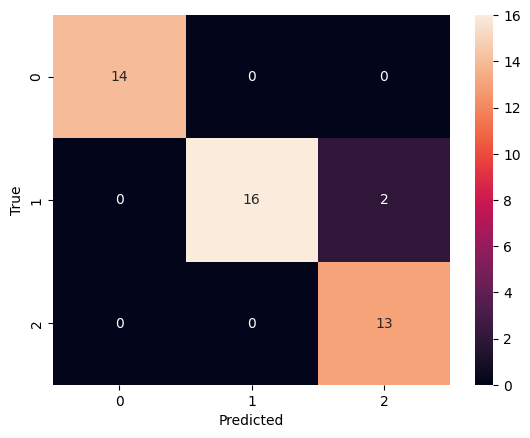

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_ = np.argmax(predictions, axis=1)
y_test_ = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_, y_pred_)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()